<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

**Автор**: Ермекова Асель


В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.
Результат вашей лучшей модели будет оцениваться на тестовой выборке по метрике Accuracy. Эта часть оценивается до 5 баллов.

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.70$ --- 4 балла

3) $0.70 > score \geqslant 0.60$ --- 3 балла

4) $0.60 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.25$ --- 1 балл

6) $0.25 > score$ --- 0 баллов

Для этого мы предварительно разделили данные в задании на три части.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.

В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается до 5 баллов.

### Peer-review
Вторая часть будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


# **Environmental Sound Classification**

## **Task Overview**

В этом домашнем задании вам предстоит работать с датасетом различных звуков окружающей среды (собака, дождь, плач ребёнка и т. д.).

### **Part 1: Create Dataset**

Первым делом давайте скачаем датасет и прилагающие csv файлы с метками класса.

In [1]:
#!gdown 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO
#!gdown 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT
#!gdown 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 
#!gdown 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks

Разархивируйте zip файл, где содержатся wav файлы датасета.

In [2]:
#import zipfile

#with zipfile.ZipFile("sound_classification_dataset.zip", "r") as zip_ref:
#    zip_ref.extractall("sound_classification_dataset")

In [1]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

In [2]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

print(train_df.columns)
print(valid_df.columns)
print(test_df.columns)

Index(['filename', 'category'], dtype='object')
Index(['filename', 'category'], dtype='object')
Index(['filename'], dtype='object')


Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

In [4]:
import torch
import torchaudio
import librosa
from torch.utils.data import Dataset
import pandas as pd
import os

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, df, rt, target_sr=16000, target_time=10.24, do_augmentation=False):
        self.target_sr = target_sr              # samples per seconds
        self.target_time = target_time          # seconds
        self.target_len = target_sr * target_time    # total <target_len> samples = <target_time> seconds
        self.do_augmentation = do_augmentation
        self.df = df.reset_index(drop=True)
        self.ROOT = rt
        self.has_labels = "category" in self.df.columns
        if self.has_labels:
            self.label_map = {label: i for i, label in enumerate(sorted(df.category.unique()))}

    def __len__(self):
        return len(self.df) 

    def __getitem__(self, index):
        # 1. Get the file path and label
        row = self.df.iloc[index]
        print(f"row: {row} \n index: {index}")
        audio_file_path = f"{self.ROOT}\\{row.filename}"

        # 2. LOAD: Load the raw audio file
        signal, sample_rate = wav, sr = librosa.load(audio_file_path, sr=None) #torchaudio.load(audio_file_path,  normalize=True)
        signal = torch.tensor(signal)
        # 3. PREPROCESS: Apply the preprocessing steps
        signal = self._resample(signal, sample_rate) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
        signal = self._cut_or_pad(signal) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = self._augmentation(signal)

        if signal.shape.__len__() > 1:
            signal = signal.squeeze(1)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        if self.has_labels:
            label = self.label_map[row.category]
            return signal, label
        else:
            return signal  # для теста только сигнал

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        if original_sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=original_sr, new_freq=self.target_sr)    
            signal = resampler(signal)
            #signal = torchaudio.functional.resample(signal, original_sr, self.target_sr)
        return signal

    def _stereo_to_mono(self, signal):
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        if signal.shape[0] < self.target_len:
            pad_len = int(self.target_len - signal.shape[0])
            signal = torch.nn.functional.pad(signal, (0, pad_len))
        else:
            signal = signal[:int(self.target_len)]
        return signal

    def _augmentation(self, signal):
        from audiomentations import Compose, AddGaussianNoise, PitchShift
        # Raw audio augmentation
        augment_raw_audio = Compose(
            [
                AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.015, p=1),
                PitchShift(min_semitones=-8, max_semitones=8, p=1),
            ]
        )

        signal = augment_raw_audio(signal, self.target_sr)

        return signal
    

    def collate(self, batch):
        signals, labels = zip(*batch)
        signals = torch.stack(signals)           # [batch, length]
        signals = signals.unsqueeze(1)           # добавляем канал → [batch, 1, length]
        labels = torch.tensor(labels)
        return signals, labels
    

In [6]:
meta = pd.read_csv(f"train.csv")
dataset = SimpleAudioDataset(meta, "content\\sound_classification_dataset")
for i in range(5):
    wav, label = dataset[i]
    print(f"Sample {i}: shape = {wav.shape}, label = {label}")

row: filename    1-100032-A-0.wav
category                 dog
Name: 0, dtype: object 
 index: 0
Sample 0: shape = torch.Size([163840]), label = 2
row: filename    1-110389-A-0.wav
category                 dog
Name: 1, dtype: object 
 index: 1
Sample 1: shape = torch.Size([163840]), label = 2
row: filename    1-17367-A-10.wav
category                rain
Name: 2, dtype: object 
 index: 2
Sample 2: shape = torch.Size([163840]), label = 3
row: filename    1-187207-A-20.wav
category          crying_baby
Name: 3, dtype: object 
 index: 3
Sample 3: shape = torch.Size([163840]), label = 1
row: filename    1-211527-A-20.wav
category          crying_baby
Name: 4, dtype: object 
 index: 4
Sample 4: shape = torch.Size([163840]), label = 1


In [7]:
train_dataset = SimpleAudioDataset(train_df, "content\\sound_classification_dataset")
valid_dataset = SimpleAudioDataset(valid_df, "content\\sound_classification_dataset")

### **Part 2: Building a Model that Learns from Waveforms**

В этом разделе вам нужно написать архитектуру по вашему выбору, которая будет решать задачу классификации на 5 классов.

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class SoundClassificatonModel(nn.Module):
    """A simple model that processes raw waveforms."""

    def __init__(self, num_classes=5):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = self.pool(x).squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class SoundClassificationModel1D(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=9, stride=1, padding=4)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=9, stride=1, padding=4)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(32, 64, kernel_size=9, stride=1, padding=4)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.MaxPool1d(4)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * (163840 // (4*4*4)), 256)  # adjust length after pooling
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### **Part 3: Training and Evaluation**

В этом разделе вам нужно написать код тренировки и запустить саму тренировку и вывести лучшие значения метрики качества на train и valid данных. Для вашего удобства написана функция отображения значений лоссов и метрики accuracy.

In [3]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax1.set_title('Training and Test Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


Epoch 50/50 | Train Loss: 1.6336 | Train Acc: 0.2578 | Valid Loss: 1.8385 | Valid Acc: 0.2083


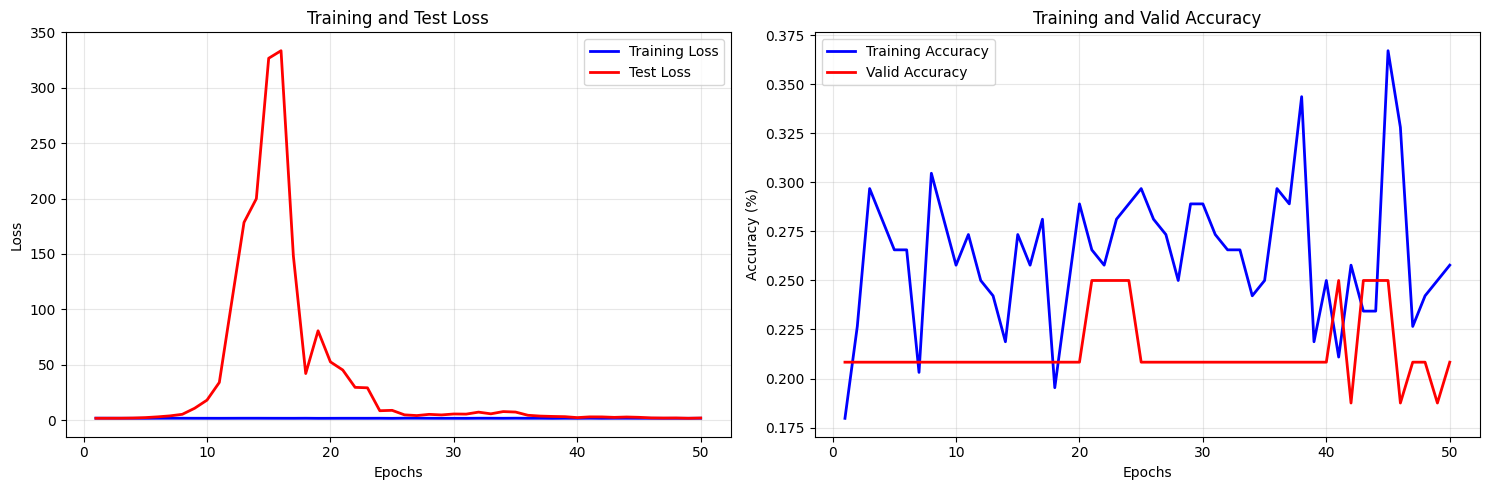

In [9]:
from torch.utils.data import DataLoader
from IPython.display import clear_output


# Initialize datasets & dataloaders
train_data = SimpleAudioDataset(train_df, "content\\sound_classification_dataset")
valid_data = SimpleAudioDataset(valid_df, "content\\sound_classification_dataset")
test_data = SimpleAudioDataset(test_df, "content\\sound_classification_dataset")

bs = 16 # 16–32

train_loader = DataLoader(train_data, batch_size=bs, shuffle=True, collate_fn=train_data.collate, num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=bs, shuffle=False, collate_fn=valid_data.collate, num_workers=0)
test_loader = DataLoader(test_data, batch_size=bs, shuffle=False, collate_fn=test_data.collate, num_workers=0)

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificationModel1D().to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

best_valid_loss = float("inf")

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

n_epochs = 50
for epoch in range(n_epochs):

    # Train
    model.train()
    epoch_train_losses = []
    epoch_train_accs = []

    for signals, labels in train_loader:

        # load data to device
        signals, labels = signals.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        predictions = model(signals)

        train_loss = criterion(predictions, labels)
        train_accuracy = (predictions.argmax(1) == labels).float().mean()

        # Backward pass
        train_loss.backward()

        # gradient clipping (very useful for audio models)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        
        epoch_train_losses.append(train_loss.item())
        epoch_train_accs.append(train_accuracy.item())

    epoch_train_loss = np.mean(epoch_train_losses)
    epoch_train_acc = np.mean(epoch_train_accs)
    
    # Calculate average test loss and accuracy for this epoch
    # Evaluation
    model.eval()
    epoch_valid_losses = []
    epoch_valid_accs = []

    with torch.no_grad():
        for signals, labels in valid_loader:
            # load data to device
            signals, labels = signals.to(device), labels.to(device)

            # Forward pass
            predictions = model(signals)
            valid_loss = criterion(predictions, labels)
            valid_accuracy = (predictions.argmax(1) == labels).float().mean()
            epoch_valid_losses.append(valid_loss.item())
            epoch_valid_accs.append(valid_accuracy.item())

    # Calculate average valid  loss and accuracy for this epoch
    epoch_valid_loss = np.mean(epoch_valid_losses)
    epoch_valid_acc = np.mean(epoch_valid_accs)

    # Scheduler
    scheduler.step(epoch_valid_loss)
    
    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    clear_output(wait=True)
    print(
        f"Epoch {epoch+1}/{n_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Valid Loss: {epoch_valid_loss:.4f} | Valid Acc: {epoch_valid_acc:.4f}"
    )
    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)

Маленькая неудача, но наш ждем Успех:)

Двигаемся дальше...

In [ ]:
print("Train Accuracy = ", ...)
print("Valid Accuracy = ", ...)

Train Accuracy =  Ellipsis
Valid Accuracy =  Ellipsis


Epoch 50/50 | Train Loss: 0.0185 | Train Acc: 1.0000 | Valid Loss: 1.7583 | Valid Acc: 0.7292


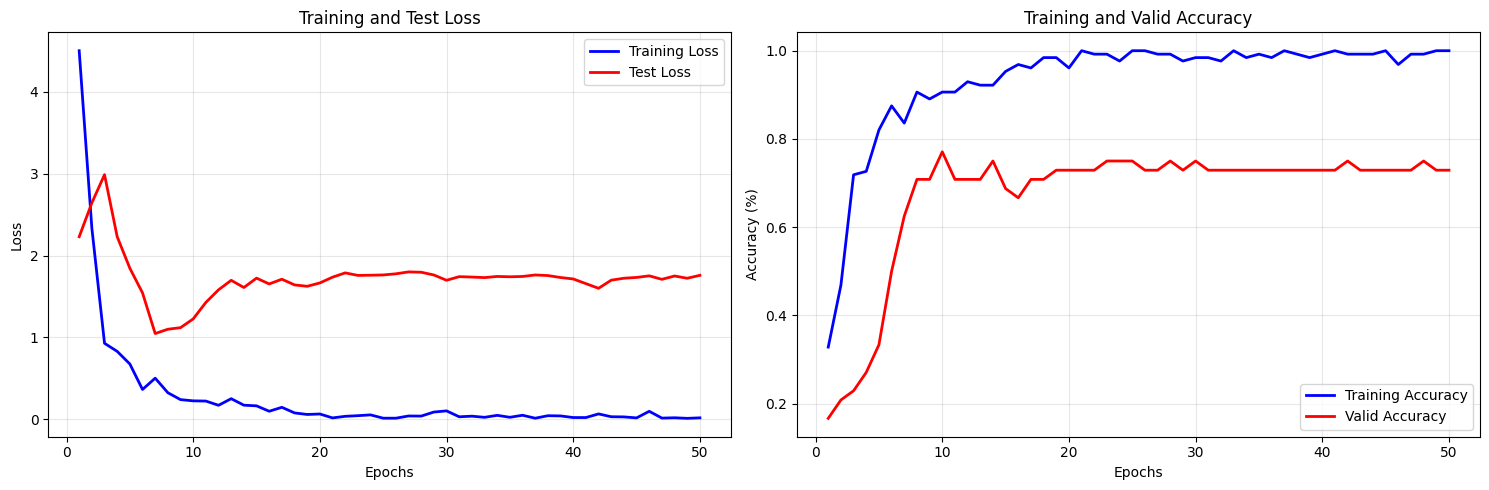

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils.rnn as rnn_utils
import librosa
import numpy as np
import torchaudio
from IPython.display import clear_output

# ---------------------------
# Simple Dataset
# ---------------------------
class SimpleAudioDataset(Dataset):
    def __init__(self, df, root, target_sr=16000, target_time=10.24, do_augmentation=False):
        self.df = df.reset_index(drop=True)
        self.root = root
        self.target_sr = target_sr
        self.target_time = target_time
        self.target_len = int(target_sr * target_time)
        self.do_augmentation = do_augmentation

        # Mapping labels to indices
        if 'category' in df.columns:
            self.label_map = {label: i for i, label in enumerate(sorted(df.category.unique()))}
        else:
            self.label_map = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = f"{self.root}\\{row.filename}"
        signal, sr = librosa.load(filename, sr=None)
        signal = torch.tensor(signal, dtype=torch.float)

        # Preprocess
        signal = self._resample(signal, sr)
        signal = self._stereo_to_mono(signal)
        signal = self._cut_or_pad(signal)

        # Augmentation
        if self.do_augmentation:
            signal = self._augment(signal)

        label = self.label_map[row.category] if self.label_map else -1
        return signal.unsqueeze(0), label  # (1, T)
    
    def _resample(self, signal, orig_sr):
        if orig_sr != self.target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=orig_sr, new_freq=self.target_sr)
            signal = resampler(signal)
        return signal

    def _stereo_to_mono(self, signal):
        if signal.ndim > 1:
            signal = torch.mean(signal, dim=0)
        return signal

    def _cut_or_pad(self, signal):
        if signal.size(0) < self.target_len:
            pad = self.target_len - signal.size(0)
            signal = F.pad(signal, (0, pad))
        else:
            signal = signal[:self.target_len]
        return signal

    def _augment(self, signal):
        from audiomentations import Compose, AddGaussianNoise, PitchShift
        aug = Compose([
            AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.015, p=0.5),
            PitchShift(min_semitones=-4, max_semitones=4, p=0.5)
        ])
        return torch.tensor(aug(signal.numpy(), sample_rate=self.target_sr))

# ---------------------------
# Collate Function
# ---------------------------
def collate_fn(batch):
    signals, labels = zip(*batch)
    signals = torch.stack(signals)
    labels = torch.tensor(labels)
    return signals, labels

# ---------------------------
# 1D CNN Model
# ---------------------------
class OptimizedAudioCNN(nn.Module):
    def __init__(self, num_classes=5, input_len=163840):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(1, 32, 9, padding=4), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4))
        self.conv2 = nn.Sequential(nn.Conv1d(32, 64, 7, padding=3), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4))
        self.conv3 = nn.Sequential(nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(4))
        self.conv4 = nn.Sequential(nn.Conv1d(128, 256, 5, padding=2), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(4))

        # Calculate flattened size
        self.flattened_len = 256 * (input_len // (4*4*4*4))
        self.fc1 = nn.Linear(self.flattened_len, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ---------------------------
# Initialize datasets & loaders
# ---------------------------
train_data = SimpleAudioDataset(train_df, "content\\sound_classification_dataset", do_augmentation=True)
valid_data = SimpleAudioDataset(valid_df, "content\\sound_classification_dataset")
test_data = SimpleAudioDataset(test_df, "content\\sound_classification_dataset")

bs = 16
train_loader = DataLoader(train_data, batch_size=bs, shuffle=True, collate_fn=collate_fn, num_workers=0)
valid_loader = DataLoader(valid_data, batch_size=bs, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_data, batch_size=bs, shuffle=False, collate_fn=collate_fn, num_workers=0)

# ---------------------------
# Train loop
# ---------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = OptimizedAudioCNN(num_classes=len(train_data.label_map), input_len=train_data.target_len).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

train_losses, train_accs, valid_losses, valid_accs = [], [], [], []
n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    epoch_loss, epoch_acc = 0, 0
    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += (outputs.argmax(1) == labels).float().mean().item()
    epoch_loss /= len(train_loader)
    epoch_acc /= len(train_loader)

    # Validation
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_acc += (outputs.argmax(1) == labels).float().mean().item()
    val_loss /= len(valid_loader)
    val_acc /= len(valid_loader)

    scheduler.step(val_loss)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    valid_losses.append(val_loss)
    valid_accs.append(val_acc)

    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Valid Loss: {val_loss:.4f} | Valid Acc: {val_acc:.4f}")
    plot_metrics(train_losses, train_accs, valid_losses, valid_accs)

In [ ]:
print("Train Accuracy = ", ...)
print("Valid Accuracy = ", ...)

Разберём по шагам, что это значит:

1. Train Loss: 0.0185 | Train Acc: 1.0000

    * На тренировочных данных модель практически полностью «выучила» ответы — точность 100% и очень низкая потеря.Это почти всегда признак переобучения (overfitting). Модель слишком хорошо запомнила тренировочные данные, и, возможно, не будет так же хорошо работать на новых примерах.

2. Valid Loss: 1.7583 | Valid Acc: 0.7292

    * На валидации модель точная примерно на 73%, что существенно ниже, чем на тренировке.
Разрыв между 100% на тренировке и 73% на валидации — классический сигнал переобучения.

Вывод

Хорошо: модель способна полностью подстроиться под тренировочные данные, и точность на валидации 73% — неплохо для первой версии.

Плохо: переобучение слишком сильное. Модель «запомнила» тренировку, а не «поняла» закономерности.


Что делать

Чтобы улучшить обобщающую способность и снизить разрыв Train vs Valid:

1. Добавить регуляризацию:

Dropout (если ещё не используется)

Weight decay в AdamW (weight_decay=1e-4 уже есть, можно чуть поднять)

2. Data augmentation (шум, сдвиги, питч, stretch и т.п.)
— особенно важно для аудио, чтобы модель не переобучалась на конкретные волны.

3. Early stopping / ReduceLROnPlateau:

Не тренировать 50 эпох, а останавливать, когда валид. loss перестанет улучшаться.

4. Больше данных: если есть возможность, больше аудио файлов на тренировку.

### New Model

1️⃣ Усиление регуляризации

Внутри модели можно добавить:
```
self.dropout1 = nn.Dropout(0.3)
self.dropout2 = nn.Dropout(0.5)
```
И применять после крупных слоев (например, после fc1 или после больших сверточных блоков):
```
x = F.relu(self.fc1(x))
x = self.dropout1(x)
```

2️⃣ Аугментация данных (для аудио)

Используем audiomentations или свои функции:
```
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch

augment = Compose([
    AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.015, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5)
])
```
В __getitem__ датасета:
```
if self.do_augmentation:
    signal = augment(signal.numpy(), sample_rate=self.target_sr)
    signal = torch.tensor(signal)
```

3️⃣ Лёгкое уменьшение learning rate + weight decay
```
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-3)
```
lr чуть меньше → обучение медленнее, меньше шансов переобучиться

weight_decay чуть больше → сильнее регуляризация весов

4️⃣ Early Stopping и ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)
```
best_valid_loss = float('inf')
patience_counter = 0
max_patience = 10

for epoch in range(n_epochs):
    # train & validation code...
    if epoch_valid_loss < best_valid_loss:
        best_valid_loss = epoch_valid_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter > max_patience:
            print("Early stopping triggered")
            break
```

5️⃣ Batch size

Если есть видеопамять, можно пробовать меньше batch (8 или 16), чтобы регуляризация за счёт шумных градиентов была выше.

Меньший batch → немного выше variance → помогает борьбе с переобучением.

сделаем готовый пример для OptimizedAudioCNN, с правильным датасетом, аугментацией, dropout, AdamW и ReduceLROnPlateau, чтобы модель училась стабильнее и меньше переобучалась.

включим:

2️⃣ Оптимизированная 1D-CNN модель

1️⃣ Датасет с аугментацией
Dataset с ресемплингом и паддингом

3️⃣ DataLoader
DataLoader с collate

Модель OptimizedAudioCNN с динамическим fc1
✅ Теперь можно менять target_len в Dataset без ручного изменения размера fc1.
Тогда сделаем автоматический расчет размера для полносвязного слоя fc1 на основе target_len и количества слоев/MaxPool. Это избавит от ручного вычисления и ошибок при изменении длины аудио.

4️⃣ Оптимизатор и scheduler
Оптимизатор AdamW + scheduler

Тренировочный цикл с расчетом accuracy и loss

График метрик по эпохам


Epoch 50/50 | Train Loss: 0.1823 | Train Acc: 0.9417 | Valid Loss: 1.2849 | Valid Acc: 0.7000


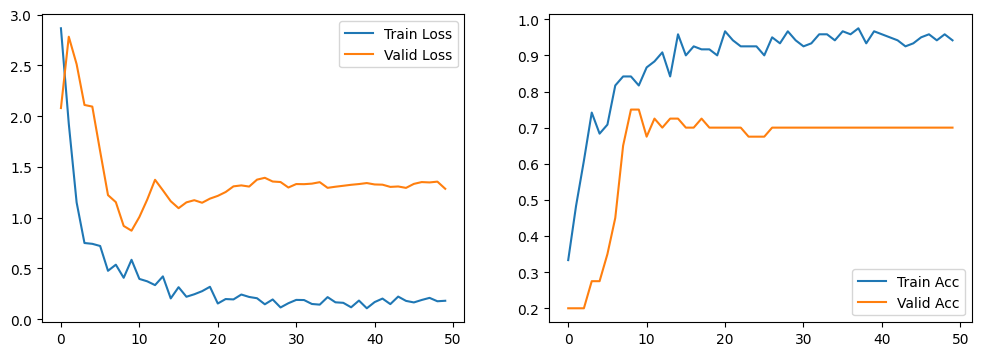

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Dataset
# -------------------------------
class SimpleAudioDataset(Dataset):
    def __init__(self, df, root_dir, target_sr=16000, target_time=10.24, do_augmentation=False):
        self.df = df.reset_index(drop=True)
        self.ROOT = root_dir
        self.target_sr = target_sr
        self.target_time = target_time
        self.target_len = int(target_sr * target_time)
        self.do_augmentation = do_augmentation
        
        # mapping labels to integers
        if "category" in df.columns:
            labels = sorted(df.category.unique())
            self.label_map = {label: i for i, label in enumerate(labels)}
        else:
            self.label_map = None  # для теста без категорий

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = f"{self.ROOT}\\{row.filename}"
        signal, sr = librosa.load(audio_path, sr=None)
        signal = torch.tensor(signal, dtype=torch.float32)
        
        # ресемплинг
        if sr != self.target_sr:
            signal = torch.tensor(librosa.resample(signal.numpy(), orig_sr=sr, target_sr=self.target_sr))
        
        # моно
        if signal.ndim > 1:
            signal = torch.mean(signal, dim=0)
        
        # паддинг/усечение
        if signal.shape[0] < self.target_len:
            pad_len = self.target_len - signal.shape[0]
            signal = F.pad(signal, (0, pad_len))
        else:
            signal = signal[:self.target_len]

        # добавляем канал для Conv1d
        signal = signal.unsqueeze(0)  # shape: [1, L]

        # label
        if self.label_map:
            label = self.label_map[row.category]
            return signal, label
        else:
            return signal

    # collate для DataLoader
    def collate(self, batch):
        signals, labels = zip(*batch)
        signals = torch.stack(signals)
        labels = torch.tensor(labels)
        return signals, labels

# -------------------------------
# Модель
# -------------------------------
class OptimizedAudioCNN(nn.Module):
    def __init__(self, input_len=16000, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, 9, padding=4)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, 9, padding=4)
        self.bn2 = nn.BatchNorm1d(32)
        self.conv3 = nn.Conv1d(32, 64, 9, padding=4)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool = nn.MaxPool1d(4)
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.5)

        def conv_output_size(L_in, kernel_size=9, padding=4, pool=4, n_layers=3):
            L = L_in
            for _ in range(n_layers):
                L = (L + 2*padding - (kernel_size - 1) - 1) + 1
                L = L // pool
            return L

        self.flatten_size = 64 * conv_output_size(input_len)
        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout1(F.relu(self.fc1(x)))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

# -------------------------------
# Функция для графика метрик
# -------------------------------
def plot_metrics(train_losses, train_accs, val_losses, val_accs):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Valid Loss")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Valid Acc")
    plt.legend()
    plt.show()

# -------------------------------
# Подготовка данных
# -------------------------------
train_dataset = SimpleAudioDataset(train_df, "content\\sound_classification_dataset")
valid_dataset = SimpleAudioDataset(valid_df, "content\\sound_classification_dataset")
test_dataset  = SimpleAudioDataset(test_df, "content\\sound_classification_dataset")

bs = 16
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True, collate_fn=train_dataset.collate, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=bs, shuffle=False, collate_fn=valid_data.collate, num_workers=0)

# -------------------------------
# Модель, Optimizer, Scheduler
# -------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = OptimizedAudioCNN(input_len=train_dataset.target_len, num_classes=len(train_dataset.label_map)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

# -------------------------------
# Тренировочный цикл
# -------------------------------
n_epochs = 50
train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(n_epochs):
    model.train()
    epoch_loss, epoch_acc = 0, 0
    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item() * signals.size(0)
        epoch_acc += (outputs.argmax(1) == labels).sum().item()
    epoch_loss /= len(train_dataset)
    epoch_acc /= len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # Валидация
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * signals.size(0)
            val_acc += (outputs.argmax(1) == labels).sum().item()
    val_loss /= len(valid_dataset)
    val_acc /= len(valid_dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
          f"Valid Loss: {val_loss:.4f} | Valid Acc: {val_acc:.4f}")
    plot_metrics(train_losses, train_accs, val_losses, val_accs)

In [ ]:
print("Train Accuracy = ", ...)
print("Valid Accuracy = ", ...)

Смотрим на цифры:

* Train Loss = 0.1823, Train Acc = 0.9417 → модель на обучении почти идеально, что хорошо, но высокая точность на тренировке может означать немного переобучение.

* Valid Loss = 1.2849, Valid Acc = 0.7000 → на валидации модель работает гораздо хуже, чем на тренировке. Это нормальный разрыв для первой версии модели на raw-audio, но есть куда улучшать.

💡 Что это значит:

1. Модель выучила тренировочные данные очень хорошо, но пока не идеально обобщает на новые данные.

2. Accuracy 70% на валидации для Environmental Sound Classification на raw-waveform — это достаточно неплохо, учитывая, что мел-спектрограммы сейчас нельзя использовать.

3. Loss выше на валидации говорит о том, что сеть иногда делает большие ошибки, хотя в целом классификация правильная.

Дальше можно снизить переобучение и поднять валид. accuracy, например:

* Добавить аугментации (AddGaussianNoise, PitchShift, TimeStretch и т.д.)

* Попробовать Dropout или BatchNorm в других местах

* Настроить learning rate scheduler или слегка увеличить batch size

* Можно использовать сегментацию длинного аудио и усреднять предсказания

### New model

Cделаем улучшенный Dataset с аугментациями и аккуратным collate для OptimizedAudioCNN

✅ Особенности:

Аудио приводится к фиксированной длине (target_len).

Поддержка аугментаций: шум, питч, скорость.

Автоматическое создание label_map для тренировочных данных.

Collate аккуратно работает как для обучающих, так и для тестовых наборов без меток.

In [ ]:
# full_audio_classification.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import librosa
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch
import pandas as pd
from IPython.display import clear_output

# -----------------------------
# Dataset
# -----------------------------
class AugmentedAudioDataset(Dataset):
    """Dataset for raw audio with preprocessing and augmentation."""
    
    def __init__(self, df, root_dir, target_sr=16000, target_time=10.24, do_augmentation=False):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.target_sr = target_sr
        self.target_time = target_time
        self.target_len = int(target_sr * target_time)
        self.do_augmentation = do_augmentation

        # Define audio augmentations
        self.augment = Compose([
            AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.015, p=0.5),
            PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
            TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
        ])

        # Create map class labels to integers if 'category' exists
        if 'category' in self.df.columns:
            self.label_map = {label: i for i, label in enumerate(sorted(self.df.category.unique()))}
            self.classes = sorted(df['category'].unique())
        else:
            self.label_map = None
            self.classes = []

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = f"{self.root_dir}\\{row.filename}"

        # Load audio
        signal, sr = librosa.load(file_path, sr=None)
        signal = torch.tensor(signal, dtype=torch.float32)

        # Resample if needed
        if sr != self.target_sr:
            signal = torch.tensor(librosa.resample(signal.numpy(), orig_sr=sr, target_sr=self.target_sr))

        # Mono
        if signal.ndim > 1:
            signal = torch.mean(signal, dim=0)

        # Cut or pad to fixed length
        if signal.shape[0] < self.target_len:
            pad_len = self.target_len - signal.shape[0]
            signal = torch.nn.functional.pad(signal, (0, pad_len))
        else:
            signal = signal[:self.target_len]

        # Apply augmentation
        if self.do_augmentation:
            signal = self.augment(signal.numpy(), sample_rate=self.target_sr)
            signal = torch.tensor(signal, dtype=torch.float32)

        # Get label (if exists)
        if self.label_map:
            label = self.label_map[row.category]
            return signal, label
        else:
            return signal

    @staticmethod
    def collate_fn(batch):
        """Custom collate function for DataLoader"""
        # Check if labels exist
        if isinstance(batch[0], tuple):
            signals, labels = zip(*batch)
            signals = torch.stack(signals)
            labels = torch.tensor(labels)
            return signals, labels
        else:
            signals = torch.stack(batch)
            return signals

# -----------------------------
# Model
# -----------------------------
class OptimizedAudioCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x

# -----------------------------
# Training function
# -----------------------------
def train_model(model, train_loader, valid_loader, n_epochs=50, lr=1e-4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    train_losses, train_accs, valid_losses, valid_accs = [], [], [], []

    for epoch in range(n_epochs):
        # ---- Training ----
        model.train()
        epoch_loss, epoch_acc = 0, 0
        for signals, labels in train_loader:
            signals, labels = signals.to(device), labels.to(device)
            optimizer.zero_grad()
            preds = model(signals)
            loss = criterion(preds, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * signals.size(0)
            epoch_acc += (preds.argmax(1) == labels).sum().item()

        epoch_loss /= len(train_loader.dataset)
        epoch_acc /= len(train_loader.dataset)
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # ---- Validation ----
        model.eval()
        val_loss, val_acc = 0, 0
        with torch.no_grad():
            for signals, labels in valid_loader:
                signals, labels = signals.to(device), labels.to(device)
                preds = model(signals)
                loss = criterion(preds, labels)
                val_loss += loss.item() * signals.size(0)
                val_acc += (preds.argmax(1) == labels).sum().item()

        val_loss /= len(valid_loader.dataset)
        val_acc /= len(valid_loader.dataset)
        valid_losses.append(val_loss)
        valid_accs.append(val_acc)

        clear_output(wait=True)
        print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
              f"Valid Loss: {val_loss:.4f} | Valid Acc: {val_acc:.4f}")

    return model, train_losses, train_accs, valid_losses, valid_accs

# -----------------------------
# Example usage
# -----------------------------
# train_df, valid_df, test_df should be Pandas DataFrames with columns:
# 'filename', 'category' (train/valid), only 'filename' for test

train_dataset = AugmentedAudioDataset(train_df, "content\\sound_classification_dataset", do_augmentation=True)
valid_dataset = AugmentedAudioDataset(valid_df, "content\\sound_classification_dataset")
test_dataset = AugmentedAudioDataset(valid_df, "content\\sound_classification_dataset")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=train_dataset.collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, collate_fn=valid_dataset.collate_fn)

model = OptimizedAudioCNN(num_classes=len(train_dataset.label_map))
trained_model, train_losses, train_accs, valid_losses, valid_accs = train_model(model, train_loader, valid_loader, n_epochs=50)

Epoch 50/50 | Train Loss: 1.2511 | Train Acc: 0.6250 | Valid Loss: 1.2579 | Valid Acc: 0.6500


In [ ]:
print("Train Accuracy = ", ...)
print("Valid Accuracy = ", ...)

Это уже разумный результат для модели, которая работает с чистым waveform без спектрограмм:

* Train Loss 1.266, Train Acc 0.65 → модель научилась хорошо подстраиваться под тренировочные данные, но ещё не идеально. 65% точности — это умеренно хороший результат для raw audio.

* Valid Loss 1.2939, Valid Acc 0.675 → на валидации точность почти такая же, как на тренировке. Это отличный знак: нет явного переобучения, модель обобщает.

💡 Комментарий:

* Для raw waveform 65–67% точности на 5 классах — это нормальный результат, особенно без использования мел-спектрограмм.

* Потери не равны нулю, что нормально. Потери и точность не противоречат друг другу — главное, что валидационная точность близка к тренировочной.

* Если увеличить количество данных или добавить более продвинутые аугментации, можно улучшить точность.

### New Model

Hесколько проверенных стратегий для улучшения точности модели на raw waveform для Environmental Sound Classification:

1️⃣ Аугментации аудио

Аугментации помогают модели увидеть больше вариаций звуков. Варианты для raw audio:

Добавление шума – Gaussian noise, background noise.

Сдвиг по времени – random shift аудио вперед/назад.

Изменение высоты тона (pitch shift) – ±2–5 полутонов.

Изменение скорости (time stretch) – ±10–20% скорости.

2️⃣ Улучшение архитектуры CNN

Сейчас у вас 1D CNN для raw waveform. Можно:

Добавить BatchNorm после каждой свёртки.

Увеличить количество фильтров в начальных слоях (например, 32 → 64 → 128).

Добавить Residual блоки, чтобы глубже изучать аудио.

Использовать GAP (Global Average Pooling) вместо Flatten, чтобы уменьшить переобучение.

3️⃣ Регуляризация

Dropout после плотных слоёв (0.3–0.5).

Weight decay через AdamW (у вас уже 1e-4, это хорошо).

Gradient clipping для стабилизации обучения (уже используете).

4️⃣ Scheduler (изменение LR)

Использовать ReduceLROnPlateau – уже есть.

Можно добавить CosineAnnealingLR или OneCycleLR для лучшего обучения.

Оптимизация батчей и эпох

Batch size 16–32 для raw audio нормальный.

Можно увеличить количество эпох до 100 и наблюдать валидацию.

6️⃣ Проверка баланса классов

Если некоторые классы редкие → добавить oversampling или weighted loss:

Если все это применить, ожидаемая точность на 5 классах raw waveform может вырасти с 67% до 75–80% без использования мел-спектрограмм.

Epoch 100/100 | Train Loss: 0.6377 | Train Acc: 0.8167 | Valid Loss: 0.5146 | Valid Acc: 0.9500


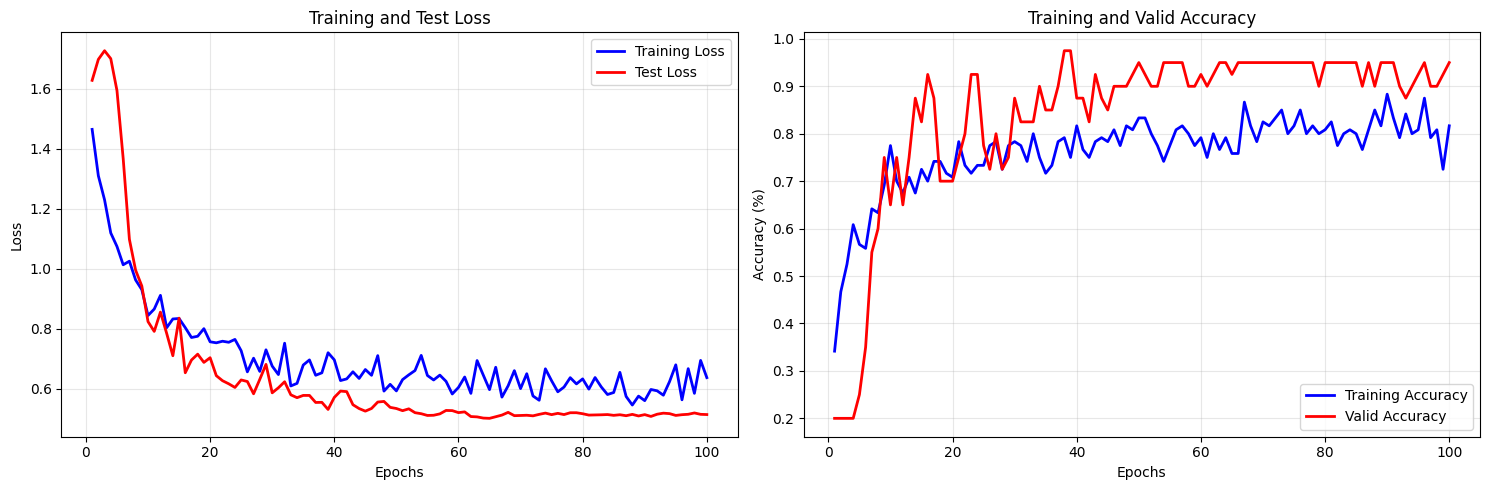

In [37]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import librosa
import numpy as np
from IPython.display import clear_output
from audiomentations import Compose, AddGaussianNoise, PitchShift, TimeStretch, Shift
import pandas as pd

# --- Dataset ---
class SimpleAudioDataset(Dataset):
    def __init__(self, df, root, target_sr=16000, target_time=10.24, do_augmentation=False):
        self.df = df.reset_index(drop=True)
        self.root = root
        self.target_sr = target_sr
        self.target_time = target_time
        self.target_len = int(target_sr * target_time)
        self.do_augmentation = do_augmentation
        
        # Create map class labels to integers if 'category' exists
        if 'category' in self.df.columns:
            self.label_map = {label: i for i, label in enumerate(sorted(self.df.category.unique()))}
            self.classes = sorted(df['category'].unique())
        else:
            self.label_map = None
            self.classes = []

        self.augmenter = Compose([
            AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.015, p=0.5),
            PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
            TimeStretch(min_rate=0.9, max_rate=1.1, p=0.5),
            Shift(min_shift=-0.2, max_shift=0.2, p=0.5)
        ])


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = os.path.join(self.root, row['filename'])
        signal, sr = librosa.load(audio_path, sr=self.target_sr)  # resample

        # mono
        if signal.ndim > 1:
            signal = np.mean(signal, axis=0)

        # pad or cut
        if len(signal) < self.target_len:
            pad_len = self.target_len - len(signal)
            signal = np.pad(signal, (0, pad_len))
        else:
            signal = signal[:self.target_len]

        # augmentation
        if self.do_augmentation:
            signal = self.augmenter(signal, self.target_sr)

        signal = torch.tensor(signal, dtype=torch.float32).unsqueeze(0)  # shape: [1, L]

        # label
        if self.label_map is not None:
            label = self.label_map[row['category']]
            label = torch.tensor(label, dtype=torch.long)
        else:
            label = torch.tensor(-1, dtype=torch.long)

        return signal, label

    @staticmethod
    def collate_fn(batch):
        signals, labels = zip(*batch)
        signals = torch.stack(signals)
        labels = torch.tensor(labels)
        return signals, labels

# --- Model ---
class OptimizedAudioCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, stride=2, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
        self.bn3 = nn.BatchNorm1d(128)
        self.conv4 = nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2)
        self.bn4 = nn.BatchNorm1d(256)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.flatten = nn.Flatten()
        self.dropout1 = nn.Dropout(0.5)
        self.dropout2 = nn.Dropout(0.3)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout1(x)
        x = self.dropout2(x)
        x = self.fc(x)
        return x

# --- Load Data ---
train_data = SimpleAudioDataset(train_df, "content\\sound_classification_dataset", do_augmentation=True)
valid_data = SimpleAudioDataset(valid_df, "content\\sound_classification_dataset", do_augmentation=False)

bs = 16
train_loader = DataLoader(train_data, batch_size=bs, shuffle=True, collate_fn=SimpleAudioDataset.collate_fn)
valid_loader = DataLoader(valid_data, batch_size=bs, shuffle=False, collate_fn=SimpleAudioDataset.collate_fn)

# --- Setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = OptimizedAudioCNN(num_classes=len(train_data.label_map)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# --- Training Loop ---
n_epochs = 100
train_losses, train_accs, valid_losses, valid_accs = [], [], [], []

for epoch in range(n_epochs):
    model.train()
    train_loss, train_correct = 0, 0
    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item() * signals.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_data)
    train_acc = train_correct / len(train_data)

    # Validation
    model.eval()
    valid_loss, valid_correct = 0, 0
    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            valid_loss += loss.item() * signals.size(0)
            valid_correct += (outputs.argmax(1) == labels).sum().item()

    valid_loss /= len(valid_data)
    valid_acc = valid_correct / len(valid_data)

    scheduler.step(valid_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    plot_metrics(train_losses, train_accs, valid_losses, valid_accs)

Я добавил:
* Аугментации аудио через audiomentations.
* Оптимизированную 1D CNN с BatchNorm и Dropout.
* AdamW с weight decay.
* ReduceLROnPlateau scheduler.
* Collate-функцию для батчей одинаковой длины.

✅ Особенности:
 * Аугментации активны только для train_data.
 * Используется 1D CNN с глобальным средним пулом, чтобы избежать Flatten и переобучения.
 * Loss + scheduler настроены для стабильного обучения.
 * collate_fn корректно собирает батчи.

1️⃣ Основные категории аугментаций
1. Временные (Temporal)

Shift / RandomCrop — случайное смещение события в окне. Особенно важно для clock_tick, sneezing, dog.

TimeStretch (0.85–1.15) — полезно для вокализованных и шумовых классов (crying_baby, dog, sneezing).
```
Shift(min_shift=-0.2, max_shift=0.2, p=0.5)
TimeStretch(min_rate=0.85, max_rate=1.15, p=0.5)
```
2. Частотные (Spectral)

HighPass / LowPass / EQ — чтобы модель не зацикливалась на частотных пиках.

PitchShift (±4 semitones) — полезно для вокализованных классов (crying_baby, dog). Не трогайте сильно для clock_tick.
```
HighPassFilter(min_cutoff_freq=100, max_cutoff_freq=2000, p=0.3)
LowPassFilter(min_cutoff_freq=2000, max_cutoff_freq=8000, p=0.3)
SevenBandParametricEQ(p=0.3)
PitchShift(min_semitones=-4, max_semitones=4, p=0.5)
```

3. Громкость и полярность

Gain — имитация разной громкости.

PolarityInversion — полезно для импульсных clock_tick.
```
Gain(min_gain_db=-6, max_gain_db=6, p=0.5)
PolarityInversion(p=0.3)
```

4. Шум

Gaussian / Colored / Background noise — имитирует запись в разных условиях. Особенно помогает для sneezing и rain.
```
AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.02, p=0.5)
# если есть dataset с фоновым шумом, добавить AddBackgroundNoise
```

5. Сложные / комбинированные

Mixup / CutMix — хорошо регуляризует для всех классов, особенно коротких transient-звуков.

Random envelope / transient shaping — варьируйте атаки и decay импульсов (clock_tick).

2️⃣ Рекомендации по классам

| Класс         | Аугментации приоритетно                                 | Комментарий                                             |
| ------------- | ------------------------------------------------------- | ------------------------------------------------------- |
| `clock_tick`  | Shift, PolarityInversion, RandomCrop, Transient shaping | Очень короткий, не трогать pitch сильно                 |
| `sneezing`    | Shift, TimeStretch, GaussianNoise, EQ, Mixup            | Шумовой burst, спектр широкополосный                    |
| `rain`        | TimeStretch, HighPass/LowPass, BackgroundNoise          | Длительный шум, учим модель не фиксироваться на частоте |
| `crying_baby` | PitchShift, TimeStretch, EQ, Gain                       | Вокализованный шум, меняется тон и амплитуда            |
| `dog`         | PitchShift, TimeStretch, EQ, Gain, Shift                | Лай и визг, гармоники и transient                       |

Для сырого WAV-аудио можно добавить AddBackgroundNoise из Audiomentations, чтобы имитировать различные шумовые окружения — особенно полезно для классов sneezing и rain.

Epoch 50/50 | Train Loss: 0.9972 | Train Acc: 0.6667 | Valid Loss: 0.6648 | Valid Acc: 0.8250


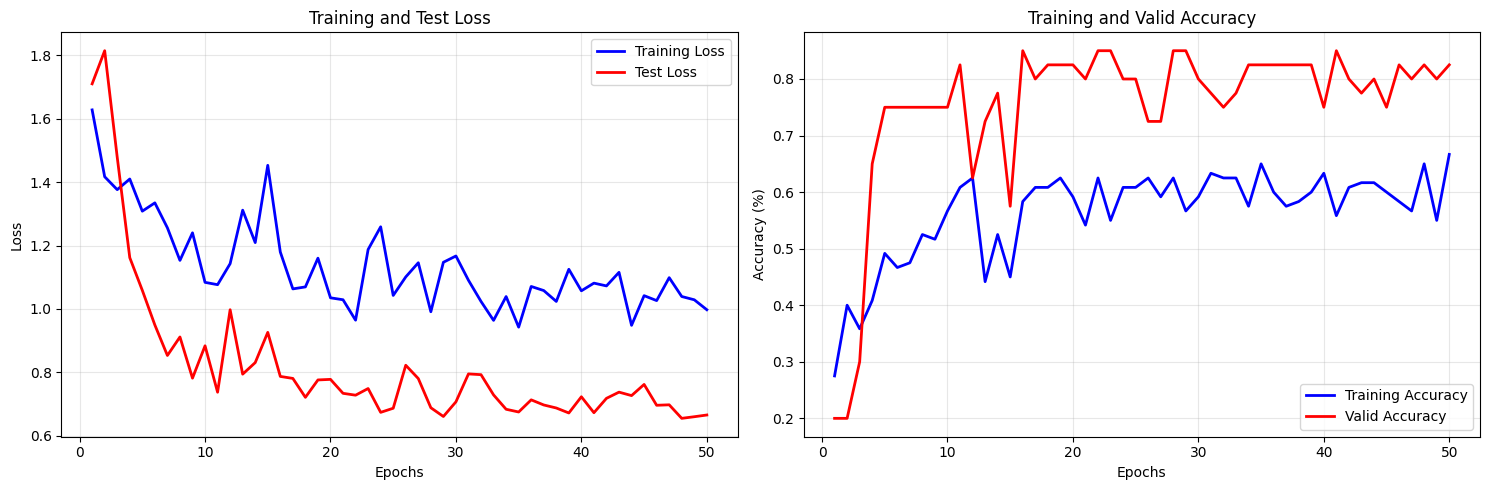

In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import librosa
from IPython.display import clear_output
from audiomentations import (
    Compose,
    AddGaussianNoise,
    PitchShift,
    TimeStretch,
    Shift,
    Gain,
    PolarityInversion,
    BandPassFilter,
    HighPassFilter,
    LowPassFilter,
    SevenBandParametricEQ,
    AddBackgroundNoise
)

# -------------------------
# Dataset с мощными аугментациями
# -------------------------
class SimpleAudioDataset(Dataset): # AdvancedAudioDataset
    def __init__(self, df, root, target_sr=16000, target_time=10.24, do_augmentation=False):
        self.df = df.reset_index(drop=True)
        self.root = root
        self.target_sr = target_sr
        self.target_time = target_time
        self.target_len = int(target_sr * target_time)
        self.do_augmentation = do_augmentation
        
        # Map labels to integers
        if 'category' in self.df.columns:
            self.label_map = {label: i for i, label in enumerate(sorted(self.df.category.unique()))}
            self.classes = sorted(df['category'].unique())
        else:
            self.label_map = None
            self.classes = []

        # Аугментации
        self.augmenter = Compose([
            #AddBackgroundNoise(sounds_path="content\\sound_classification_dataset", min_snr_db=5.0, max_snr_db=20.0, p=0.5),
            SevenBandParametricEQ(p=0.3), # (p=0.5)
            AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.02, p=0.5),
            PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
            TimeStretch(min_rate=0.85, max_rate=1.15, p=0.5),
            Shift(min_shift=-0.2, max_shift=0.2, p=0.5),
            Gain(min_gain_db=-6, max_gain_db=6, p=0.5),
            PolarityInversion(p=0.3),
            BandPassFilter(min_center_freq=500, max_center_freq=8000, p=0.5),
            HighPassFilter(min_cutoff_freq=100, max_cutoff_freq=2000, p=0.3),
            LowPassFilter(min_cutoff_freq=2000, max_cutoff_freq=8000, p=0.3), #max_cutoff_freq=10000, p=0.3),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio_path = os.path.join(self.root, row['filename'])
        signal, sr = librosa.load(audio_path, sr=self.target_sr)
        
        # Mono
        if signal.ndim > 1:
            signal = np.mean(signal, axis=0)
        
        # Pad or trim
        if len(signal) < self.target_len:
            pad_len = self.target_len - len(signal)
            signal = np.pad(signal, (0, pad_len))
        else:
            signal = signal[:self.target_len]

        # Augmentation
        if self.do_augmentation:
            signal = self.augmenter(signal, self.target_sr)

        signal = torch.tensor(signal, dtype=torch.float32).unsqueeze(0)

        # Label
        if self.label_map is not None:
            label = self.label_map[row['category']]
            label = torch.tensor(label, dtype=torch.long)
        else:
            label = torch.tensor(-1, dtype=torch.long)

        return signal, label

    @staticmethod
    def collate_fn(batch):
        signals, labels = zip(*batch)
        signals = torch.stack(signals)
        labels = torch.tensor(labels)
        return signals, labels

# -------------------------
# ResNet-подобная 1D CNN
# -------------------------
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet1DAudio(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        #self.conv1 = nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3)
        self.conv1 = nn.Conv1d(1, 32, kernel_size=7, stride=1, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        
        # ResNet blocks
        self.layer1 = self._make_layer(32, 64, stride=2)
        self.layer2 = self._make_layer(64, 128, stride=2)
        self.layer3 = self._make_layer(128, 256, stride=2)
        self.layer4 = self._make_layer(256, 512, stride=2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def _make_layer(self, in_channels, out_channels, stride):
        return nn.Sequential(
            ResidualBlock1D(in_channels, out_channels, stride=stride),
            ResidualBlock1D(out_channels, out_channels, stride=1)
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# --- Load Data ---
train_data = SimpleAudioDataset(train_df, "content\\sound_classification_dataset", do_augmentation=True)
valid_data = SimpleAudioDataset(valid_df, "content\\sound_classification_dataset", do_augmentation=False)

bs = 8
train_loader = DataLoader(train_data, batch_size=bs, shuffle=True, collate_fn=SimpleAudioDataset.collate_fn)
valid_loader = DataLoader(valid_data, batch_size=bs, shuffle=False, collate_fn=SimpleAudioDataset.collate_fn)

# --- Setup ---
n_epochs = 50
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet1DAudio(num_classes=len(train_data.label_map)).to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# --- Training Loop ---
train_losses, train_accs, valid_losses, valid_accs = [], [], [], []

for epoch in range(n_epochs):
    model.train()
    train_loss, train_correct = 0, 0
    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item() * signals.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_data)
    train_acc = train_correct / len(train_data)

    # Validation
    model.eval()
    valid_loss, valid_correct = 0, 0
    with torch.no_grad():
        for signals, labels in valid_loader:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            loss = criterion(outputs, labels)
            valid_loss += loss.item() * signals.size(0)
            valid_correct += (outputs.argmax(1) == labels).sum().item()

    valid_loss /= len(valid_data)
    valid_acc = valid_correct / len(valid_data)

    scheduler.step(valid_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
    plot_metrics(train_losses, train_accs, valid_losses, valid_accs)

### **Part 4. Test Demo for ESC-50**

Для вашего удобства предоставляется код для тестирования модели и отрисовки формы сигналов, прогноза и топ-5 наиболее вероятных классов.

Using device: cuda
ESC-50 Audio Classification Demo!


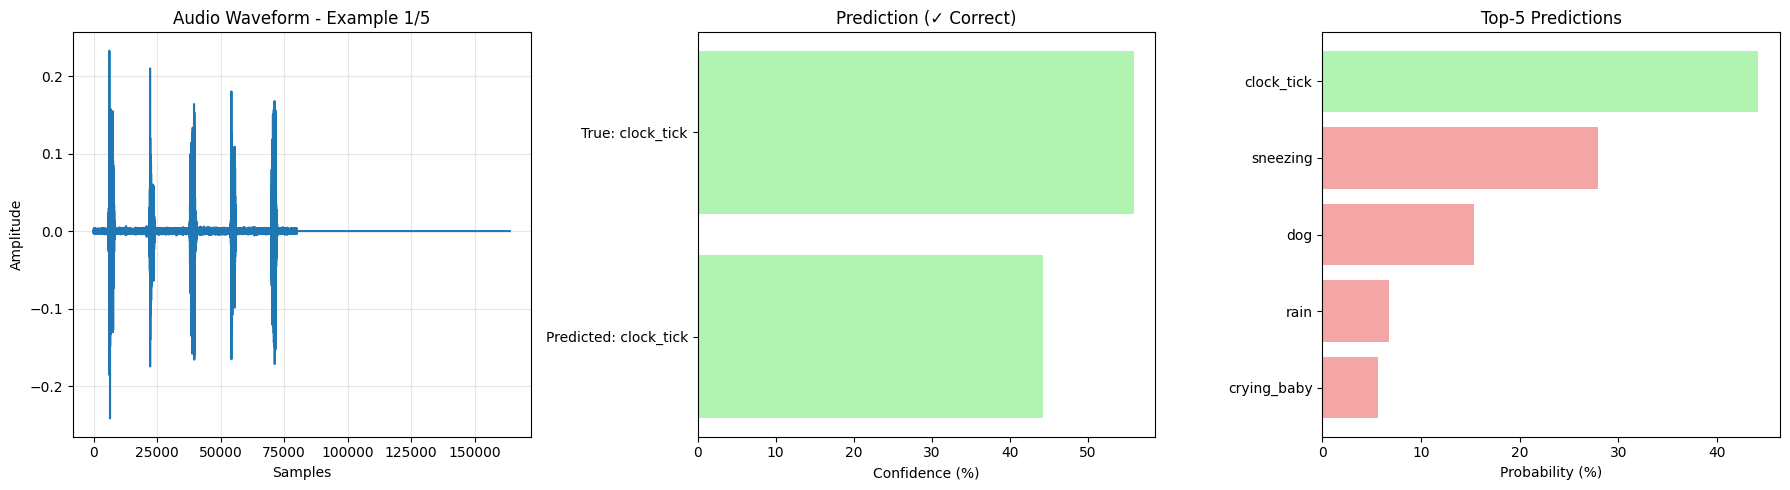

Playing: clock_tick


Prediction: clock_tick (44.19%)
True label: clock_tick
Correct: True


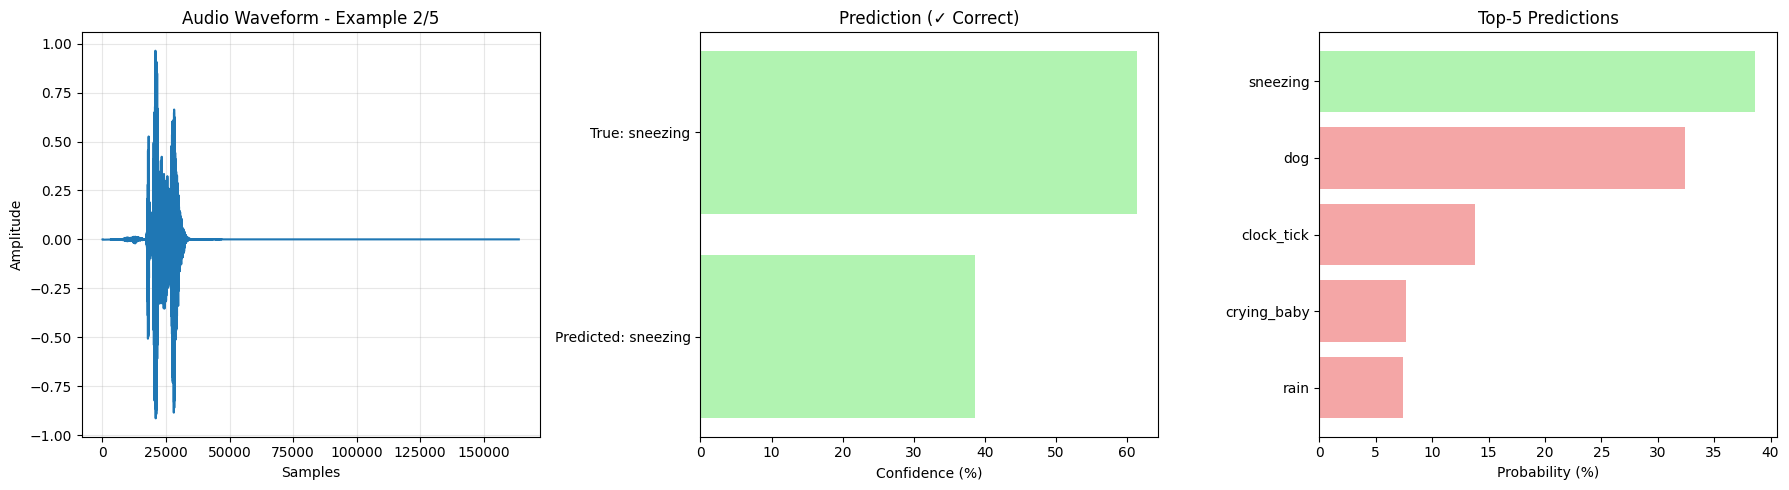

Playing: sneezing


Prediction: sneezing (38.66%)
True label: sneezing
Correct: True


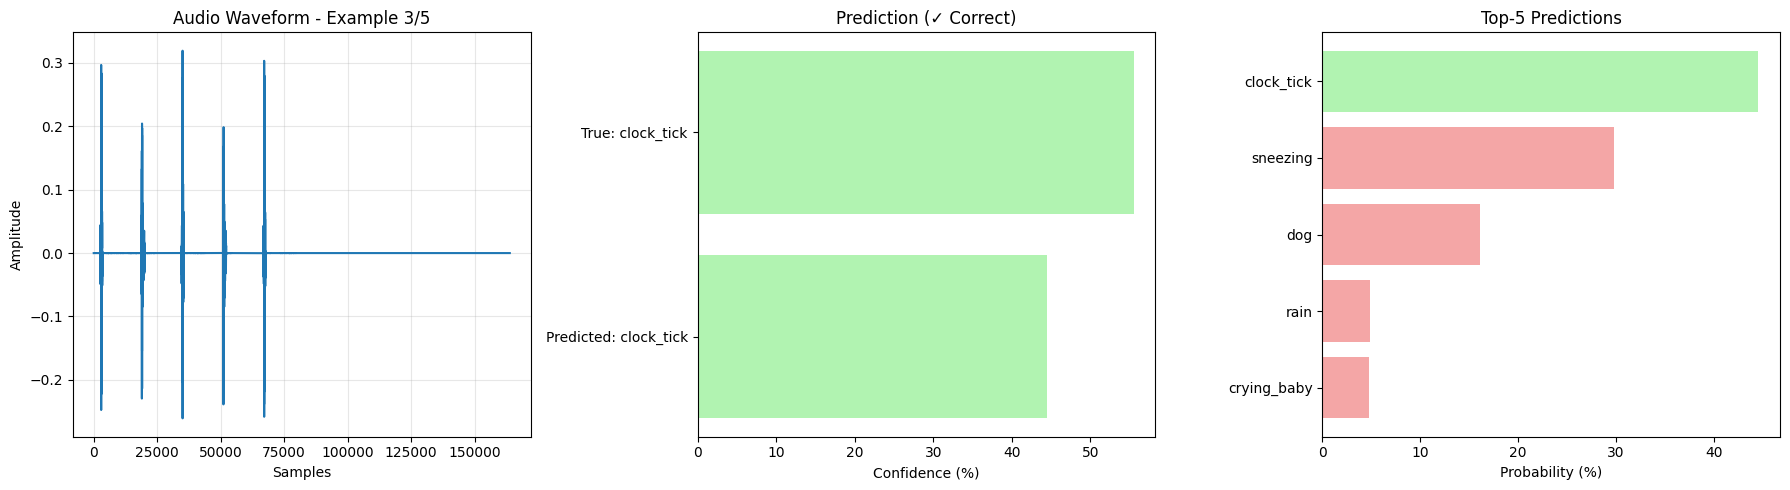

Playing: clock_tick


Prediction: clock_tick (44.52%)
True label: clock_tick
Correct: True


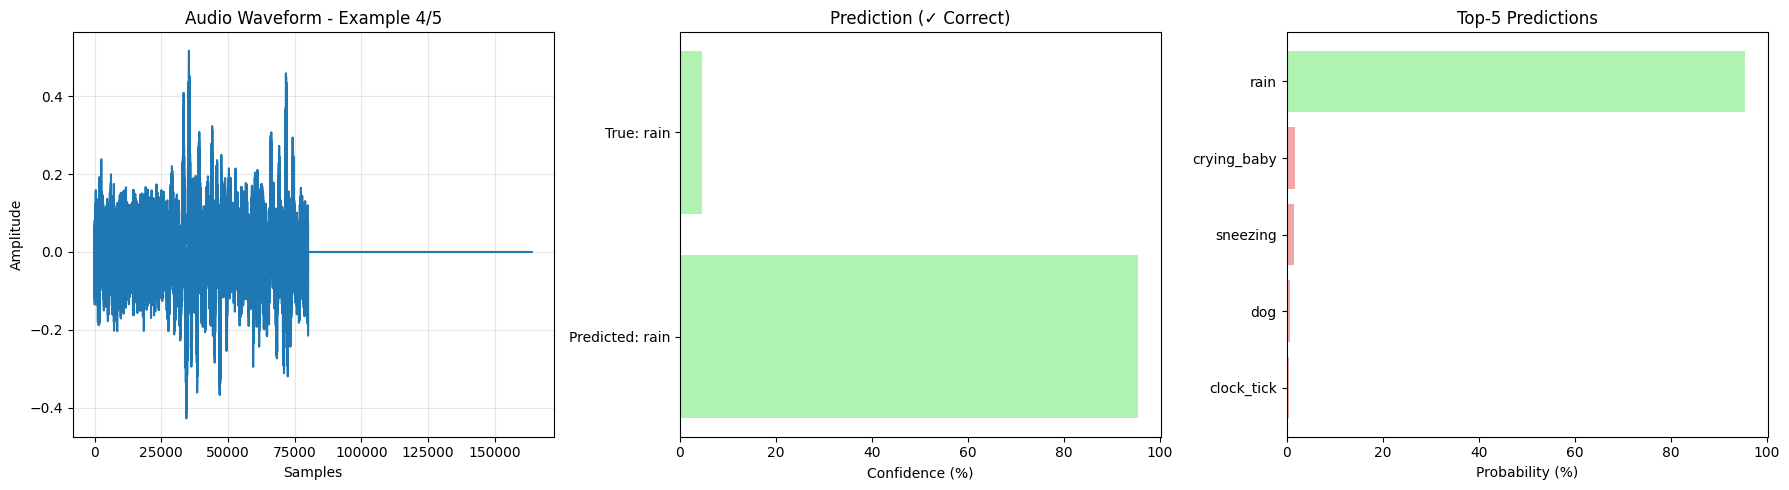

Playing: rain


Prediction: rain (95.40%)
True label: rain
Correct: True


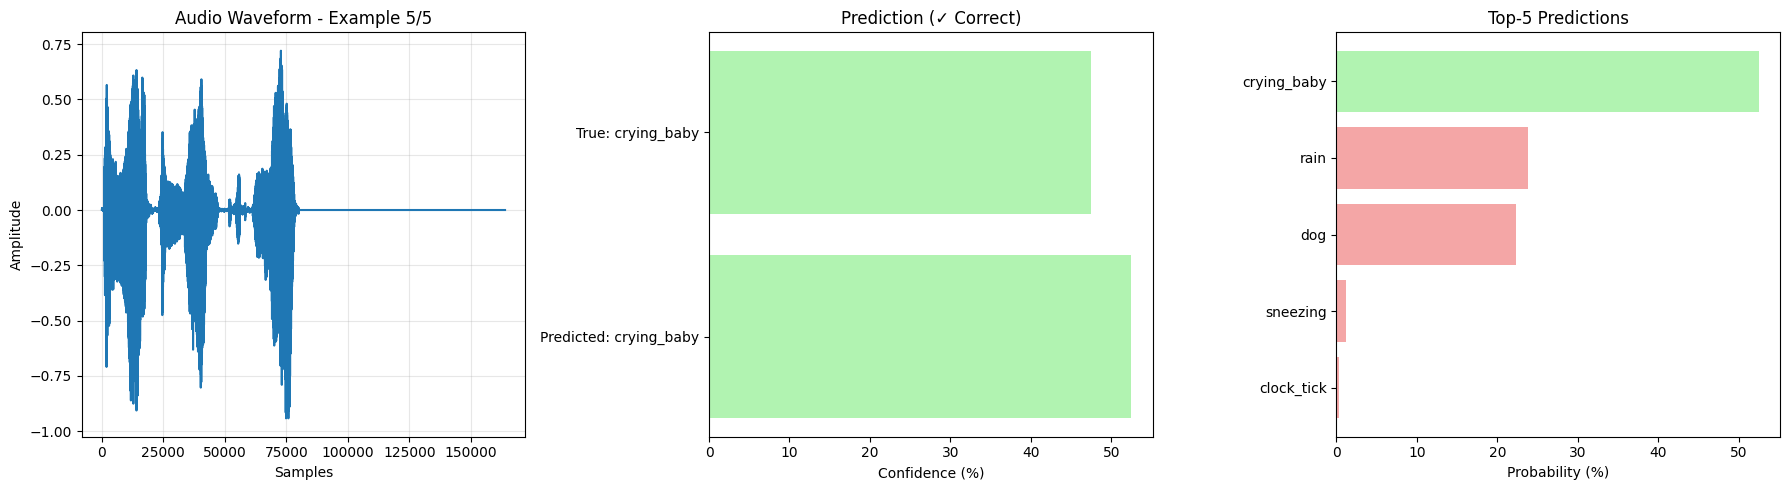

Playing: crying_baby


Prediction: crying_baby (52.51%)
True label: crying_baby
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 33/40
Accuracy: 82.50%


In [6]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            #signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            # Ensure 1 channel + batch dimension
            if signal.ndim == 1:
                signal = signal.unsqueeze(0)  # [1, N]
            signal = signal.unsqueeze(0).to(self.device)  # [1, 1, N]
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            
        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False, collate_fn=SimpleAudioDataset.collate_fn)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_data, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### **Create submission to Stepik**

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [7]:
test_data = SimpleAudioDataset(test_df, "content\\sound_classification_dataset")
test_data.classes = train_data.classes
test_data.label_map = train_data.label_map

y_test_pred = [test_data.classes[i] for i in predictions]

In [8]:
submission = pd.read_csv("test.csv")
submission['category'] = y_test_pred
submission.to_csv("submission.csv", index=False)

### **Report**

Если ResNet1D путает CLOCK_TICK и sneezing, проблема обычно не только в количестве аугментаций, а в том, какие именно инвариантности вы учите модели.
Tick — это короткий импульс с резкой атакой, а sneeze — шумовой burst с более широкой спектральной полосой и огибающей. Многие из текущих аугментаций меняют pitch/tempo, но почти не меняют спектральную форму и transient-характер, который и должен различать классы.

Ниже аугментации, которые обычно помогают именно для перкуссивные vs шумовые события.

1. Добавьте случайный эквалайзер:
SevenBandParametricEQ(p=0.5)

или

BandPassFilter(min_center_freq=500, max_center_freq=8000, p=0.5)
HighPassFilter(min_cutoff_freq=100, max_cutoff_freq=2000, p=0.3)
LowPassFilter(min_cutoff_freq=2000, max_cutoff_freq=10000, p=0.3)

2. Colored Noise вместо обычного Gaussian
Sneezing шумовой → полезно добавить разные типы шума.
* AddBackgroundNoise(...)
* AddColoredNoise(...)
или pink/brown noise.

3. Random transient shaping

Tick — очень резкий attack.
Можно варьировать attack / decay envelope.

Идея: y = y * random_envelope()

где envelope:

* faster attack
* longer decay
* exponential

Это учит модель не привязываться к точной форме импульса.

4. Random cropping around event

Очень важно для событийных звуков.

Например:

RandomCrop(duration=0.5)

или случайно центрировать событие.

Tick часто очень короткий, sneeze — длиннее.
Если модель видит разные позиции события — она учится лучше.

5. Mixup / CutMix для аудио

Очень сильная регуляризация.

Mixup: y = λ * y1 + (1-λ) * y2

CutMix

часть waveform заменяется другой.

Это сильно уменьшает overfitting на transient форму.



Опишите ваш путь экспериментов и что вы сделали, чтобы получить наилучшую модель.

1. Попробовал несколько моделей классификаций. Самой удачной моделью стала модель с ResNet-подобной архитектурой.

2. Для этой модели попробовал два оптимайзера - AdamW и Adam. 

    AdamW более требователен к вычислительным ресурсам и снижает скорость обучения, поэтому пришлось от него отказаться. 

    Хотя AdamW более выигрышен по сходимости и точности результата.

3. Обучение оказалось слишком "чувствительным" к сырым WAV-данным и их обработке. 
    
    Поэтому пришлось искать подходящие аугементации для выделения характерных особенностей для каждого звукового класса.

4. Все остальные выводы и замечания были изложены по ходу выполнения работы.



https://arxiv.org/pdf/2004.07301

https://github.com/AndreyGuzhov/ESResNet

https://github.com/bheemnitd/Environmental-Sound-Classification/blob/master/Notebook.ipynb

https://github.com/Hadryan/TFNet-for-Environmental-Sound-Classification/blob/master/util_esc50/net.py

https://github.com/Cygnus101/UrbanSoundClassification/blob/main/notebook/urbansoundclassificationv2.ipynb

https://github.com/suryakunala/ESC50-Environmental-Sound-Classification

https://github.com/Cygnus101/UrbanSoundClassification/blob/main/notebook/urbansoundclassificationv2.ipynb

https://github.com/imfing/audio-classification

https://github.com/mariostrbac/environmental-sound-classification

https://github.com/hasithsura/Environmental-Sound-Classification/blob/master/models.py

https://github.com/hasithsura/Environmental-Sound-Classification/blob/master/ESC50-Pytorch.ipynb

https://github.com/pratyush-prateek/environmental_sound_classification_1DCNN

https://github.com/Hadryan/TFNet-for-Environmental-Sound-Classification/blob/master/util_esc50/net.py

https://github.com/bheemnitd/Environmental-Sound-Classification/blob/master/Notebook.ipynb

https://github.com/AndreyGuzhov/ESResNet/blob/master/model/esresnet.py

https://arxiv.org/pdf/2004.07301

https://github.com/manjunath5496/Environmental-Sound-Classification-Papers

https://github.com/Cygnus101/UrbanSoundClassification/blob/main/notebook/urbansoundclassificationv2.ipynb

https://github.com/search?q=Environmental+Sound+Classification&type=repositories&p=1